# Classificação — CNN treinada em MNIST

Carrega os pesos salvos por `train.cpp` (`--model-out`) e classifica dígitos do conjunto de teste (`data/test.bin`), mostrando a imagem ao lado da previsão. Para a apresentação: rode as células em ordem, depois troque `idx` na célula "Escolha uma imagem" para mostrar outros exemplos.

In [2]:
import struct

import matplotlib.pyplot as plt
import numpy as np

MODEL_PATH = "../model.bin"
DATA_PATH = "../data/test.bin"

ARCH = [
    ("conv1.W", (6, 1, 5, 5)), ("conv1.b", (6,)),
    ("conv2.W", (16, 6, 5, 5)), ("conv2.b", (16,)),
    ("fc1.W", (120, 256)), ("fc1.b", (120,)),
    ("fc2.W", (84, 120)), ("fc2.b", (84,)),
    ("fc3.W", (10, 84)), ("fc3.b", (10,)),
]

Matplotlib is building the font cache; this may take a moment.


## Carregar pesos e dados

`load_model` lê o binário raw salvo por `network.cpp:lenet_save_params` (10 vetores, cada um `uint64` de tamanho + `float32[tamanho]`, na ordem fixa da arquitetura).

`load_mnist_bin` lê o mesmo formato que `mnist.cpp`/`prepare_mnist.py` usam para `train.bin`/`test.bin`.

In [3]:
def load_model(path):
    params = {}
    with open(path, "rb") as f:
        for name, shape in ARCH:
            n = struct.unpack("<Q", f.read(8))[0]
            expected = int(np.prod(shape))
            if n != expected:
                raise ValueError(f"{path}: shape incompativel em {name} "
                                  f"(esperado {expected}, lido {n})")
            arr = np.frombuffer(f.read(n * 4), dtype="<f4").astype(np.float64)
            params[name] = arr.reshape(shape)
    return params


def load_mnist_bin(path):
    with open(path, "rb") as f:
        n, rows, cols = struct.unpack("<III", f.read(12))
        pixels = np.frombuffer(f.read(n * rows * cols * 4), dtype="<f4").astype(np.float64)
        images = pixels.reshape(n, rows, cols)
        labels = np.frombuffer(f.read(n), dtype=np.uint8).astype(np.int64)
    return images, labels


params = load_model(MODEL_PATH)
images, labels = load_mnist_bin(DATA_PATH)
print(f"modelo carregado de {MODEL_PATH}")
print(f"{len(images)} imagens de teste carregadas de {DATA_PATH}")

modelo carregado de ../model.bin
10000 imagens de teste carregadas de ../data/test.bin


## Forward pass (mesma arquitetura de `gradient_check.py`, sem o backward)

`Conv(1→6,5x5) → ReLU → MaxPool2x2 → Conv(6→16,5x5) → ReLU → MaxPool2x2 → FC(256→120) → ReLU → FC(120→84) → ReLU → FC(84→10) → Softmax`

In [4]:
def conv_forward(W, b, x):
    out_c, in_c, kh, kw = W.shape
    _, h, w = x.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    y = np.empty((out_c, out_h, out_w))
    for oc in range(out_c):
        acc = np.full((out_h, out_w), b[oc])
        for ic in range(in_c):
            for i in range(kh):
                for j in range(kw):
                    acc += W[oc, ic, i, j] * x[ic, i:i + out_h, j:j + out_w]
        y[oc] = acc
    return y


def relu(x):
    return np.maximum(x, 0.0)


def maxpool2x2(x):
    c, h, w = x.shape
    out_h, out_w = h // 2, w // 2
    return x.reshape(c, out_h, 2, out_w, 2).max(axis=(2, 4))


def dense_forward(W, b, x):
    return W @ x + b


def softmax(logits):
    exps = np.exp(logits - logits.max())
    return exps / exps.sum()


def predict(params, image_28x28):
    x0 = image_28x28.reshape(1, 28, 28)
    c1 = relu(conv_forward(params["conv1.W"], params["conv1.b"], x0))
    p1 = maxpool2x2(c1)
    c2 = relu(conv_forward(params["conv2.W"], params["conv2.b"], p1))
    p2 = maxpool2x2(c2)
    flat = p2.reshape(-1)
    r3 = relu(dense_forward(params["fc1.W"], params["fc1.b"], flat))
    r4 = relu(dense_forward(params["fc2.W"], params["fc2.b"], r3))
    logits = dense_forward(params["fc3.W"], params["fc3.b"], r4)
    probs = softmax(logits)
    digit = int(np.argmax(logits))
    return digit, probs


def show_prediction(idx):
    image, true_label = images[idx], int(labels[idx])
    digit, probs = predict(params, image)
    confidence = probs[digit]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(7, 3))
    ax_img.imshow(image, cmap="gray")
    ok = "✓" if digit == true_label else "✗"
    ax_img.set_title(f"previsto: {digit} ({confidence:.1%})  {ok}\nreal: {true_label}")
    ax_img.axis("off")

    ax_bar.bar(range(10), probs, color=["tab:green" if i == digit else "tab:blue" for i in range(10)])
    ax_bar.set_xticks(range(10))
    ax_bar.set_xlabel("dígito")
    ax_bar.set_ylabel("probabilidade")
    ax_bar.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
    return digit, true_label

## Escolha uma imagem

Troque `idx` (0 a `len(images)-1`) e rode a célula para ver outro exemplo.

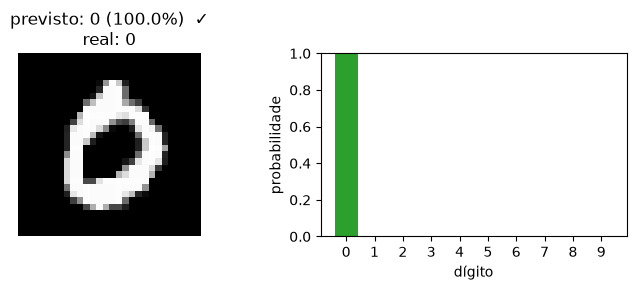

(0, 0)

In [23]:
idx = 3
show_prediction(idx)

## Vários exemplos de uma vez

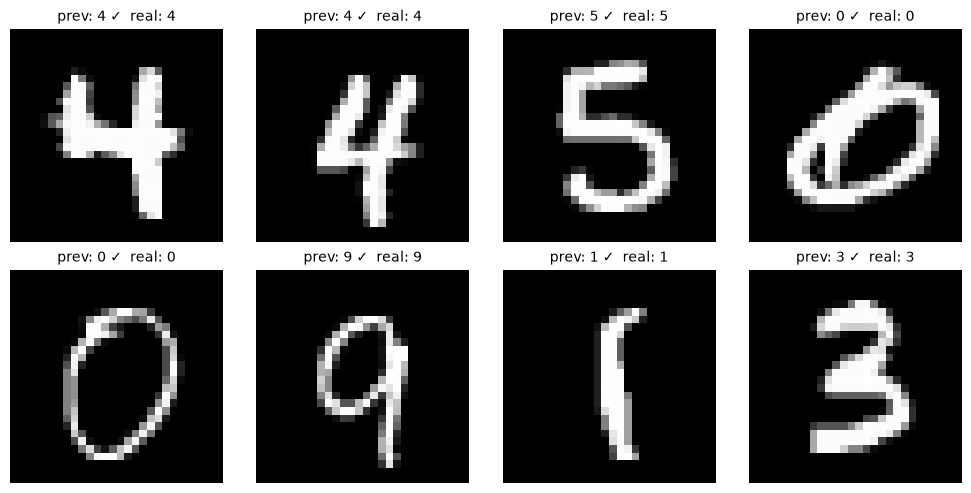

In [10]:
rng = np.random.default_rng(0)
sample_idxs = rng.choice(len(images), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.flat, sample_idxs):
    digit, probs = predict(params, images[idx])
    true_label = int(labels[idx])
    ok = "✓" if digit == true_label else "✗"
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"prev: {digit} {ok}  real: {true_label}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Acurácia sobre uma amostra do conjunto de teste

In [11]:
n_eval = 500  # sobe para len(images) para avaliar o conjunto de teste inteiro (mais lento)
eval_idxs = rng.choice(len(images), size=n_eval, replace=False)

correct = 0
for idx in eval_idxs:
    digit, _ = predict(params, images[idx])
    if digit == int(labels[idx]):
        correct += 1

print(f"acurácia em {n_eval} amostras aleatórias do teste: {correct / n_eval:.2%} ({correct}/{n_eval})")

acurácia em 500 amostras aleatórias do teste: 94.00% (470/500)
